# Toss/Turn & Scratch — Group Comparison Analysis

Compares toss/turn and scratch activity across AD severity groups (Severe / Moderate / Control) for participants with a validated PSG-EMFIT sync (`sync_status == 'OK'`).

**Analyses:**
1. Distribution of raw toss/turn and scratch counts by group
2. Distribution of toss/turn and scratch rate **per hour of true sleep** by group
3. True sleep duration by group
4. Correlations between EASI score, sleep duration, scratch rate, and toss/turn rate

**Note on sleep duration:** computed as total time scored as any stage other than `Wake` in the `Sleep.stage` column (REM/NREM not distinguished) — not the raw PSG recording window, which would include time-in-bed before/after sleep onset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, spearmanr
from pathlib import Path
import re
import itertools

sns.set_style('whitegrid')

## 1. Load data and prepare groups

In [2]:
participant_data_path = Path("C:/Users/ryadl/Desktop/EMFIT_local/Emfit_1/logs/emfit_participant_data.csv")
processed_dir = Path("C:/Users/ryadl/Desktop/EMFIT_local/Emfit_1/data/processed")

df = pd.read_csv(participant_data_path)
df = df[df['sync_status'] == 'OK'].copy()

GROUP_LABELS = {1: 'Severe', 2: 'Moderate', 3: 'Control'}
df['group'] = pd.to_numeric(df['group'], errors='coerce')
df['group_label'] = df['group'].map(GROUP_LABELS)
df['easi'] = pd.to_numeric(df['easi'], errors='coerce')

print(f"Participants with OK sync status: {len(df)}")
print(df['group_label'].value_counts(dropna=False))

Participants with OK sync status: 25
group_label
Moderate    11
Control      8
Severe       6
Name: count, dtype: int64


## 2. Compute true sleep duration (excludes Wake epochs)

In [3]:
def resolve_processed_path(row_id, processed_dir):
    """Locate the Visit_X folder in data/processed for a given row_id (e.g. 'MS8', 'MS53V1')."""
    match = re.match(r'(MS\d+)(V(\d+))?$', row_id)
    if not match:
        return None
    base_id = match.group(1)
    visit_num = match.group(3)
    participant_path = processed_dir / base_id
    if not participant_path.exists():
        return None
    if visit_num:
        visit_dir = participant_path / f"Visit_{visit_num}"
        return visit_dir if visit_dir.exists() else None
    visit_dirs = sorted(participant_path.glob("Visit_*"))
    if len(visit_dirs) != 1:
        return None
    return visit_dirs[0]


def compute_true_sleep_hours(row_id, processed_dir):
    """
    True sleep time = total seconds where Sleep.stage is scored and is not 'Wake'.
    Returns (sleep_hours, unique_stage_values) or (None, None) if unavailable.
    """
    visit_dir = resolve_processed_path(row_id, processed_dir)
    if visit_dir is None:
        return None, None

    tt_files = list(visit_dir.glob("*_acti_psg_SSandArousal_1s_tt.csv"))
    if not tt_files:
        return None, None

    tt_df = pd.read_csv(tt_files[0])
    if 'Sleep.stage' not in tt_df.columns:
        return None, None

    stages = tt_df['Sleep.stage'].dropna().str.strip()
    unique_stages = stages.str.lower().unique().tolist()

    sleep_seconds = (stages.str.lower() != 'wake').sum()
    return sleep_seconds / 3600, unique_stages


true_sleep_hours_list = []
all_unique_stages = set()
failed_sleep_calc = []

for _, row in df.iterrows():
    hours, stages = compute_true_sleep_hours(row['participant_id'], processed_dir)
    true_sleep_hours_list.append(hours)
    if stages:
        all_unique_stages.update(stages)
    if hours is None:
        failed_sleep_calc.append(row['participant_id'])

df['true_sleep_hours'] = true_sleep_hours_list

print(f"Unique Sleep.stage values found across dataset: {sorted(all_unique_stages)}")
if failed_sleep_calc:
    print(f"\nCould not compute true sleep duration for: {failed_sleep_calc}")
else:
    print("\nTrue sleep duration computed for all participants.")

Unique Sleep.stage values found across dataset: ['n1', 'n2', 'n3', 'rem', 'wake']

True sleep duration computed for all participants.


## 3. Recompute toss/turn & scratch rates per hour of TRUE sleep


In [4]:
# Recompute toss/turn and scratch rates using TRUE SLEEP TIME as the denominator
# (events per hour of actual sleep, rather than per hour of PSG recording/time-in-bed)
df['toss_turn_per_hour_sleep'] = df.apply(
    lambda r: r['toss_turn_count'] / r['true_sleep_hours']
    if pd.notna(r['true_sleep_hours']) and r['true_sleep_hours'] > 0 else np.nan,
    axis=1
)
df['scratch_per_hour_sleep'] = df.apply(
    lambda r: r['scratch_count'] / r['true_sleep_hours']
    if pd.notna(r['true_sleep_hours']) and r['true_sleep_hours'] > 0 else np.nan,
    axis=1
)

n_zero_tt = (df['toss_turn_count'] == 0).sum()
n_missing_tt = df['toss_turn_count'].isna().sum()
n_zero_scratch = (df['scratch_count'] == 0).sum()
n_missing_scratch = df['scratch_count'].isna().sum()

print(f"Toss/turn — zero events: {n_zero_tt}, missing: {n_missing_tt}")
print(f"Scratch   — zero events: {n_zero_scratch}, missing: {n_missing_scratch}")
print("\nNote: zero is treated as a genuine data point (no events detected) and kept in all analyses.")
print("Missing (NaN) values are excluded pairwise by the plotting/test functions below.")

Toss/turn — zero events: 2, missing: 0
Scratch   — zero events: 1, missing: 0

Note: zero is treated as a genuine data point (no events detected) and kept in all analyses.
Missing (NaN) values are excluded pairwise by the plotting/test functions below.


## Helper functions for plotting & testing

In [5]:
GROUP_ORDER = ['Severe', 'Moderate', 'Control']

def group_boxplot(data, value_col, title, ax, order=GROUP_ORDER):
    sns.boxplot(data=data, x='group_label', y=value_col, order=order, ax=ax, showfliers=False)
    sns.stripplot(data=data, x='group_label', y=value_col, order=order, ax=ax,
                  color='black', alpha=0.6, jitter=True)
    ax.set_title(title)
    ax.set_xlabel('')


def kruskal_by_group(data, value_col, group_col='group_label', order=GROUP_ORDER):
    groups = [data[data[group_col] == g][value_col].dropna().values for g in order]
    n_per_group = [len(g) for g in groups]
    groups_nonempty = [g for g in groups if len(g) > 0]
    if len(groups_nonempty) < 2:
        print(f"{value_col}: insufficient groups with data for Kruskal-Wallis test")
        return None, None
    stat, p = kruskal(*groups_nonempty)
    print(f"{value_col} — Kruskal-Wallis H={stat:.3f}, p={p:.4f} (n per group: {dict(zip(order, n_per_group))})")
    return stat, p

## Analysis 1 — Toss/turn count and scratch count by group

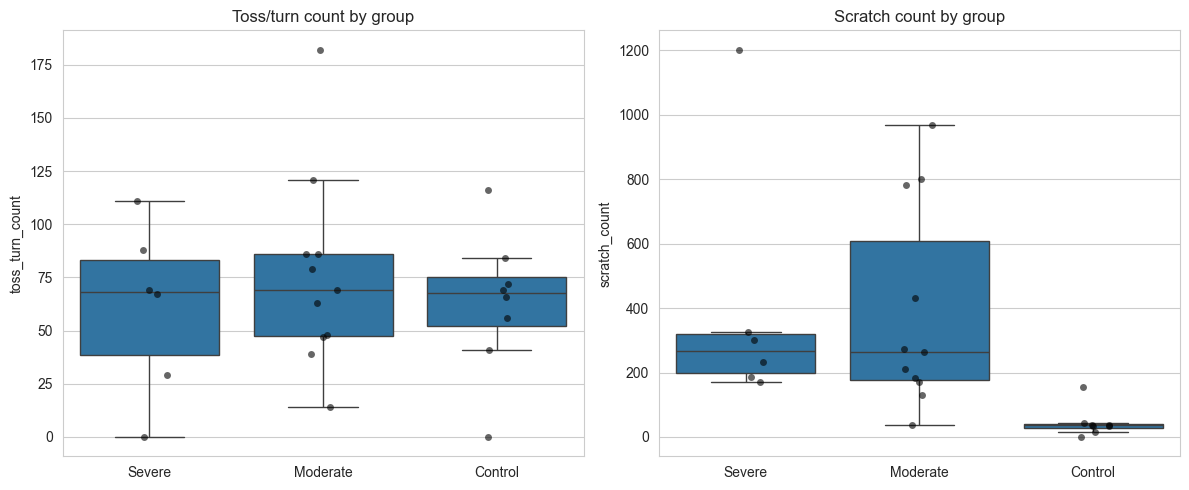


toss_turn_count — Kruskal-Wallis H=0.244, p=0.8851 (n per group: {'Severe': 6, 'Moderate': 11, 'Control': 8})
scratch_count — Kruskal-Wallis H=13.838, p=0.0010 (n per group: {'Severe': 6, 'Moderate': 11, 'Control': 8})


(np.float64(13.837927174787518), np.float64(0.0009888542706570549))

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
group_boxplot(df, 'toss_turn_count', 'Toss/turn count by group', axs[0])
group_boxplot(df, 'scratch_count', 'Scratch count by group', axs[1])
plt.tight_layout()
plt.show()

print()
kruskal_by_group(df, 'toss_turn_count')
kruskal_by_group(df, 'scratch_count')

## Analysis 2 — Toss/turn and scratch rate per hour of sleep by group

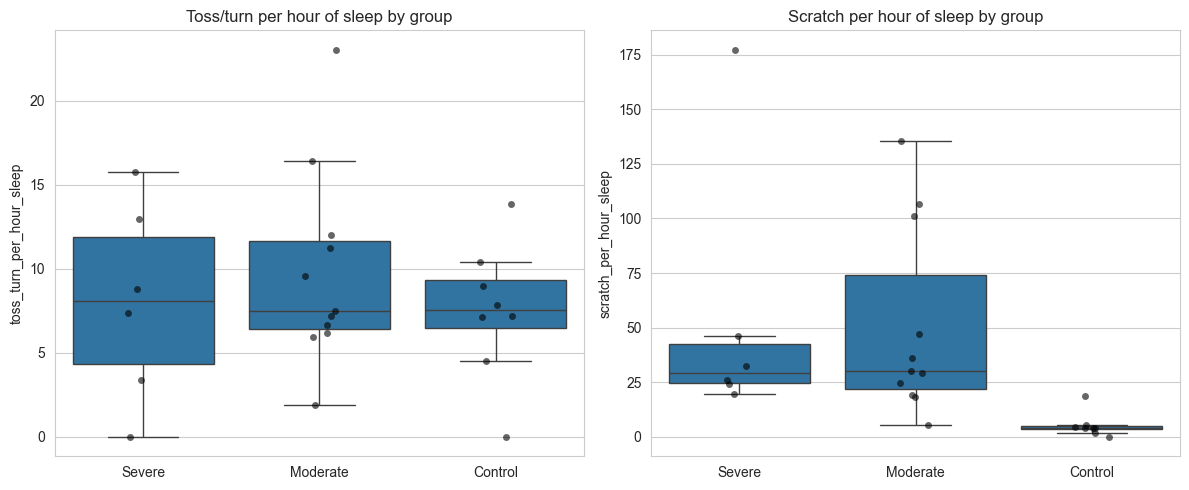


toss_turn_per_hour_sleep — Kruskal-Wallis H=0.342, p=0.8430 (n per group: {'Severe': 6, 'Moderate': 11, 'Control': 8})
scratch_per_hour_sleep — Kruskal-Wallis H=14.797, p=0.0006 (n per group: {'Severe': 6, 'Moderate': 11, 'Control': 8})


(np.float64(14.796643356643372), np.float64(0.0006122795012485985))

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
group_boxplot(df, 'toss_turn_per_hour_sleep', 'Toss/turn per hour of sleep by group', axs[0])
group_boxplot(df, 'scratch_per_hour_sleep', 'Scratch per hour of sleep by group', axs[1])
plt.tight_layout()
plt.show()

print()
kruskal_by_group(df, 'toss_turn_per_hour_sleep')
kruskal_by_group(df, 'scratch_per_hour_sleep')

## Analysis 3 — True sleep duration by group

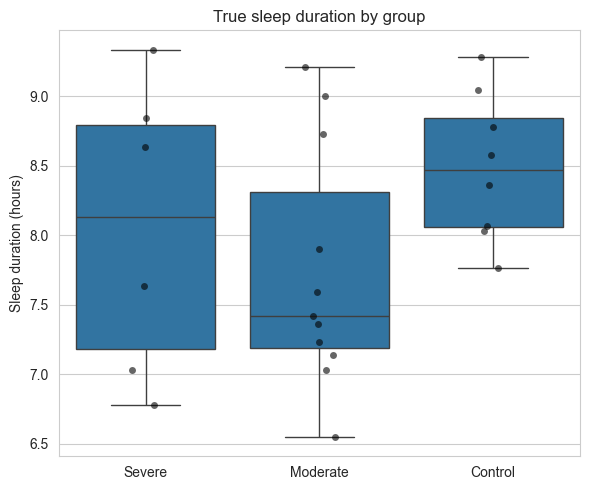


true_sleep_hours — Kruskal-Wallis H=3.540, p=0.1704 (n per group: {'Severe': 6, 'Moderate': 11, 'Control': 8})


(np.float64(3.539613137920184), np.float64(0.17036593969932676))

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
group_boxplot(df, 'true_sleep_hours', 'True sleep duration by group', ax)
ax.set_ylabel('Sleep duration (hours)')
plt.tight_layout()
plt.show()

print()
kruskal_by_group(df, 'true_sleep_hours')

## Analysis 4 — Correlations: sleep duration, scratch rate, toss/turn rate (all participants)

=== Correlations across ALL participants (n=25) ===

true_sleep_hours vs scratch_per_hour_sleep: rho=-0.355, p=0.0816, n=25
true_sleep_hours vs toss_turn_per_hour_sleep: rho=-0.315, p=0.1254, n=25
scratch_per_hour_sleep vs toss_turn_per_hour_sleep: rho=0.485, p=0.0141, n=25


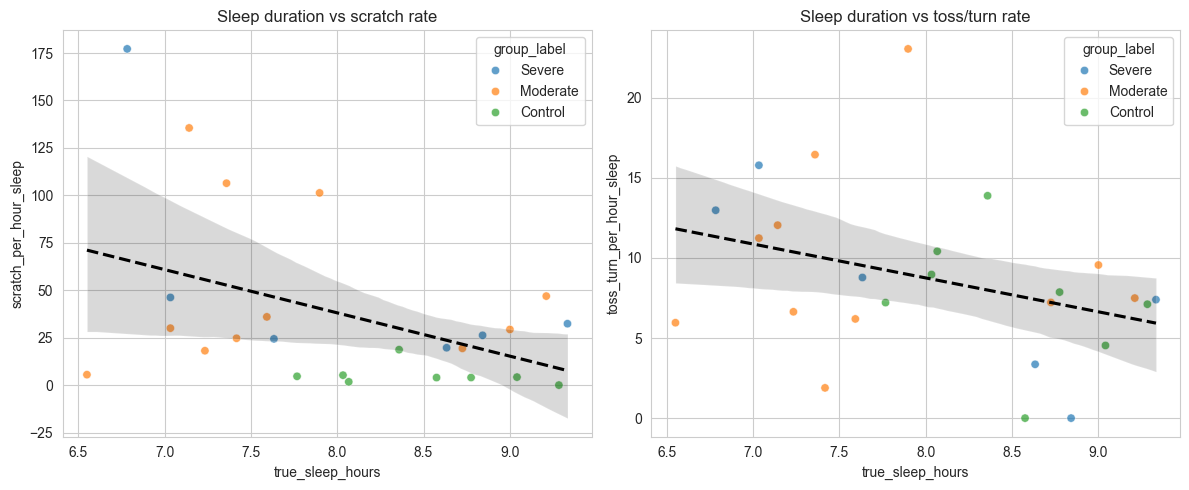

In [9]:
print(f"=== Correlations across ALL participants (n={len(df)}) ===\n")
corr_vars_all = ['true_sleep_hours', 'scratch_per_hour_sleep', 'toss_turn_per_hour_sleep']

for v1, v2 in itertools.combinations(corr_vars_all, 2):
    sub = df[[v1, v2]].dropna()
    if len(sub) < 3:
        print(f"{v1} vs {v2}: insufficient data (n={len(sub)})")
        continue
    rho, p = spearmanr(sub[v1], sub[v2])
    print(f"{v1} vs {v2}: rho={rho:.3f}, p={p:.4f}, n={len(sub)}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
pairs = [('true_sleep_hours', 'scratch_per_hour_sleep'), ('true_sleep_hours', 'toss_turn_per_hour_sleep')]
titles = ['Sleep duration vs scratch rate', 'Sleep duration vs toss/turn rate']

for ax, (x, y), title in zip(axs, pairs, titles):
    sub = df[[x, y, 'group_label']].dropna()
    sns.scatterplot(data=sub, x=x, y=y, hue='group_label', hue_order=GROUP_ORDER, ax=ax, alpha=0.7)
    sns.regplot(data=sub, x=x, y=y, ax=ax, scatter=False, color='black', line_kws={'linestyle': '--'})
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Analysis 4 (continued) — EASI correlations (Severe + Moderate only)

=== Correlations with EASI score (Severe + Moderate only, n=17) ===

easi vs true_sleep_hours: rho=-0.043, p=0.8701, n=17
easi vs scratch_per_hour_sleep: rho=0.167, p=0.5226, n=17
easi vs toss_turn_per_hour_sleep: rho=0.336, p=0.1876, n=17
true_sleep_hours vs scratch_per_hour_sleep: rho=-0.092, p=0.7255, n=17
true_sleep_hours vs toss_turn_per_hour_sleep: rho=-0.254, p=0.3256, n=17
scratch_per_hour_sleep vs toss_turn_per_hour_sleep: rho=0.718, p=0.0012, n=17


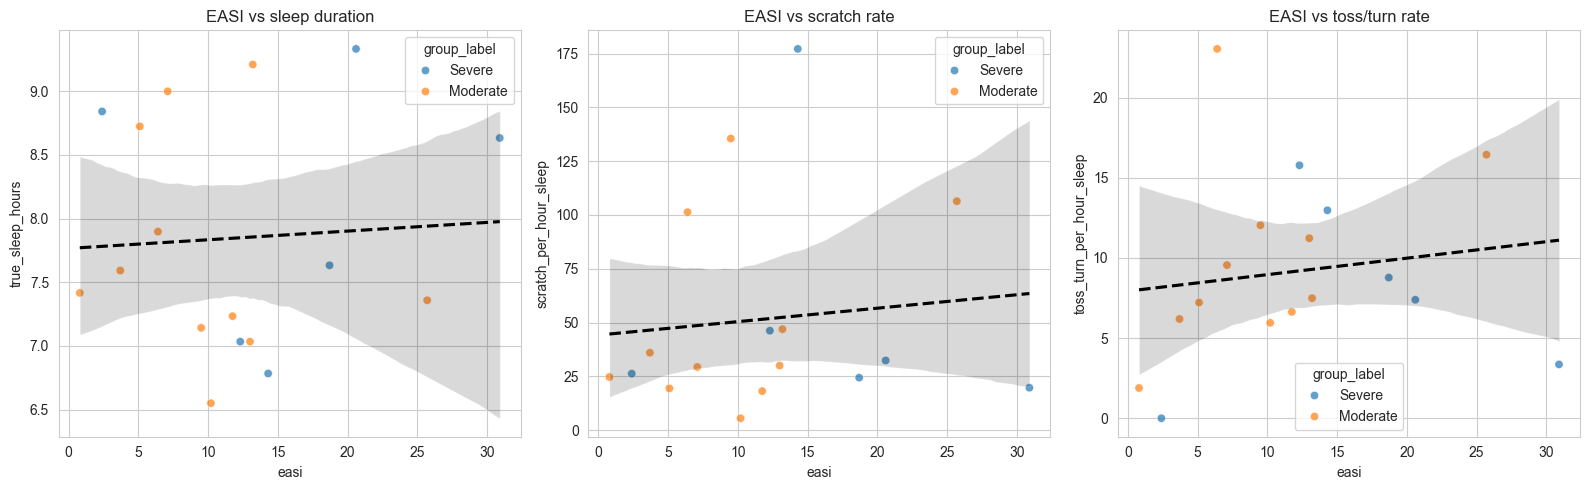

In [10]:
# EASI is undefined/not meaningful for the Control group, so EASI correlations
# are restricted to Severe + Moderate participants only.
eczema_df = df[df['group_label'].isin(['Severe', 'Moderate'])].copy()
print(f"=== Correlations with EASI score (Severe + Moderate only, n={len(eczema_df)}) ===\n")

corr_vars_easi = ['easi', 'true_sleep_hours', 'scratch_per_hour_sleep', 'toss_turn_per_hour_sleep']
for v1, v2 in itertools.combinations(corr_vars_easi, 2):
    sub = eczema_df[[v1, v2]].dropna()
    if len(sub) < 3:
        print(f"{v1} vs {v2}: insufficient data (n={len(sub)})")
        continue
    rho, p = spearmanr(sub[v1], sub[v2])
    print(f"{v1} vs {v2}: rho={rho:.3f}, p={p:.4f}, n={len(sub)}")

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('easi', 'true_sleep_hours'), ('easi', 'scratch_per_hour_sleep'), ('easi', 'toss_turn_per_hour_sleep')]
titles = ['EASI vs sleep duration', 'EASI vs scratch rate', 'EASI vs toss/turn rate']

for ax, (x, y), title in zip(axs, pairs, titles):
    sub = eczema_df[[x, y, 'group_label']].dropna()
    sns.scatterplot(data=sub, x=x, y=y, hue='group_label', hue_order=['Severe', 'Moderate'], ax=ax, alpha=0.7)
    sns.regplot(data=sub, x=x, y=y, ax=ax, scatter=False, color='black', line_kws={'linestyle': '--'})
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Notes

- **Sample size**: per-group N is small — Kruskal-Wallis (non-parametric) was used throughout rather than ANOVA, and exact group sizes are printed alongside every test for transparency.
- **Sleep duration** is defined as total time scored as any stage other than `Wake` (REM/NREM not distinguished). Revisit if a different definition is more appropriate for the dissertation.
- **EASI correlations** are restricted to Severe + Moderate participants, since EASI is not a meaningful score for the Control group.
- **Zero vs missing toss/turn data**: a zero count is treated as a genuine observation (no toss/turn events detected) and retained in all analyses. Missing (NaN) values are excluded pairwise by each test/plot, not imputed.
- All correlations use **Spearman's rho** rather than Pearson, given the small sample size and no assumption of linear/normal relationships.